In [34]:
######################################
## IMPORTS AND LIBRARY DEPENDENCIES ##
######################################

## Imports
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

## GLOBAL VARIABLES
TARGET_SLIDE = 'TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs'
FOLDER_NAME = 'TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs'
MODEL_NAME = 'model_resnet_tcga_seg_FTL_100'

## Input files
ptf_identifiers = f"/Users/user/Documents/projects/GlandSeg/outputs/V2/o1_extracted_glands/{FOLDER_NAME}/{TARGET_SLIDE}_identifiers.npy"
ptf_gland_polygons = f"/Users/user/Documents/projects/GlandSeg/outputs/V2/o1_extracted_glands/{FOLDER_NAME}/{TARGET_SLIDE}_polygons.pkl"
ptf_cluster_labels = f"/Users/user/Documents/projects/GlandSeg/outputs/V2/o2_embeddings/{FOLDER_NAME}/{MODEL_NAME}/image_identifiers_and_predicted_clusters.csv"

#
###

In [35]:
#########################################
## LOAD AND FORMAT LABELS AND POLYGONS ##
#########################################

## Load identifiers
identifiers = np.load(ptf_identifiers)

## Load the predicted cluster labels CSV
df_clusters = pd.read_csv(ptf_cluster_labels)

## Extract slide identifier from 'filename' column
df_clusters["slide_id"] = df_clusters["filename"].str.split("__").str[0]

## Filter for the target slide
df_target_slide = df_clusters[df_clusters["slide_id"] == TARGET_SLIDE]

## Load the gland polygons (pickled list of coordinates)
with open(ptf_gland_polygons, "rb") as f:
    gland_polygons = pickle.load(f)

## Check for consistency
if len(df_target_slide) != len(gland_polygons):
    print(f"Warning: Number of cluster labels ({len(df_target_slide)}) and polygons ({len(gland_polygons)}) do not match.")

#
###

In [53]:
########################################
## ALIGN POLYGONS WITH CLUSTER LABELS ##
########################################

# Remove "_mask_both" suffix from cluster filenames for comparison
df_clusters["clean_filename"] = df_clusters["filename"].str.replace("_mask_both", "", regex=False)

# Convert identifiers to comparable format
identifier_list = [os.path.basename(idf) for idf in identifiers]

# Reorder df_clusters based on identifier order
df_target_slide = df_clusters.set_index("clean_filename").loc[identifier_list].reset_index()

# Verify alignment
if not np.array_equal(df_target_slide["clean_filename"].values, identifier_list):
    print("Warning: Identifiers and cluster labels are still misaligned!")
else:
    print("Identifiers successfully aligned with cluster labels.")

## Extract cluster labels
cluster_labels = df_target_slide["predicted_cluster"].values

#
###

Identifiers successfully aligned with cluster labels.


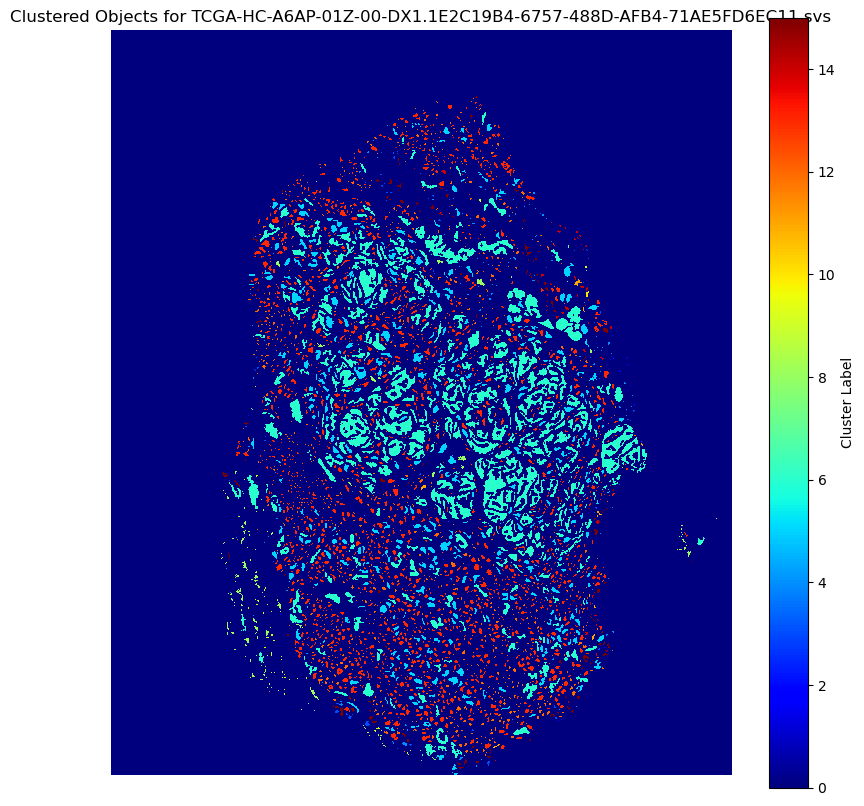

In [55]:
###############
## VISUALISE ##
###############

## Determine the image size (max coordinates to define canvas size)
all_pixels = np.concatenate(gland_polygons, axis=0)  # Flatten all points
max_x, max_y = np.max(all_pixels, axis=0)  # Get max dimensions
canvas_size = (max_y + 1, max_x + 1)  # Ensure proper shape (rows, cols)

## Create a blank image (black background)
canvas = np.zeros(canvas_size, dtype=np.uint8)

## Assign colors to each object
for pixel_coords, cluster_label in zip(gland_polygons, cluster_labels):
    pixel_array = np.array(pixel_coords)
    canvas[pixel_array[:, 1], pixel_array[:, 0]] = cluster_label  # Assign cluster label to pixels

## Display the canvas with a colormap
plt.figure(figsize=(10, 10))
plt.imshow(canvas.T, cmap="jet", interpolation="nearest")
plt.colorbar(label="Cluster Label")
plt.title(f"Clustered Objects for {TARGET_SLIDE}")
plt.axis("off")  # Hide axis for better visualization
plt.show()

#
###